# Historical  VaR and CVaR Analysis


In [3]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/02_nav_history_cleaned.csv")

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
# Convert date column
nav['date'] = pd.to_datetime(nav['date'])

# Sort values
nav = nav.sort_values(['amfi_code', 'date'])

# Daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Calculate VaR and CVaR
var_cvar = []

for fund in nav['amfi_code'].unique():
    returns = nav[nav['amfi_code'] == fund]['daily_return'].dropna()

    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    var_cvar.append([
        fund,
        var_95,
        cvar_95
    ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Report saved successfully!")

Report saved successfully!


# Rolling 90-Day Sharpe Ration Analysis

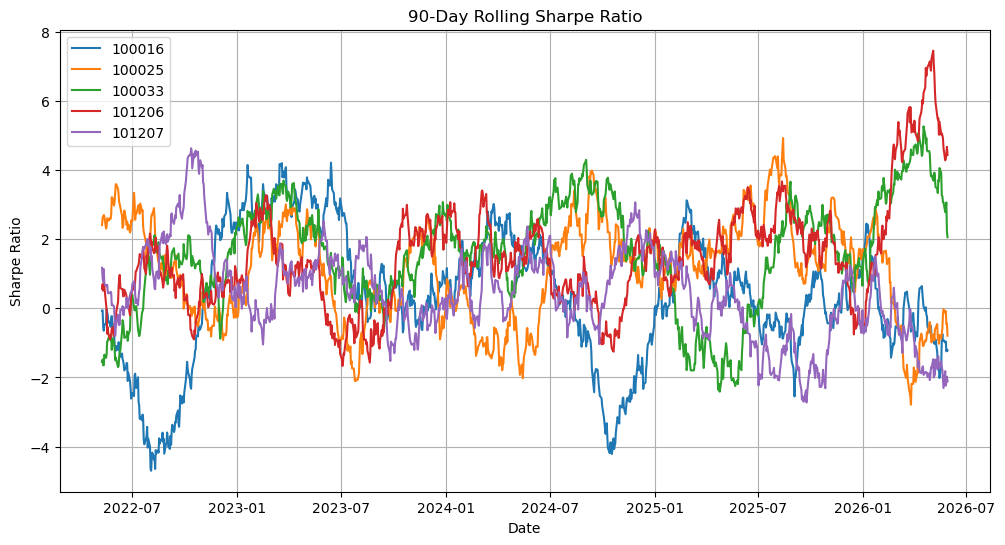

In [6]:
# Calculate daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Select 5 funds
top_funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top_funds:

    fund_data = nav[nav['amfi_code'] == fund].copy()

    rolling_sharpe = (
        fund_data['daily_return']
        .rolling(90)
        .mean()
        /
        fund_data['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        fund_data['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.show()

In [7]:
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

print("Chart saved successfully!")

Chart saved successfully!


<Figure size 640x480 with 0 Axes>

# Investor Cohort Analysis

In [8]:
investors = pd.read_csv("../data/08_investor_transactions.csv")

investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [9]:
# Convert date
investors['transaction_date'] = pd.to_datetime(investors['transaction_date'])

# First transaction year per investor
first_txn = investors.groupby('investor_id')['transaction_date'].min().reset_index()

first_txn['cohort_year'] = first_txn['transaction_date'].dt.year

# Merge back
investors = investors.merge(
    first_txn[['investor_id', 'cohort_year']],
    on='investor_id',
    how='left'
)

# Cohort summary
cohort_analysis = investors.groupby('cohort_year').agg({
    'amount_inr': ['mean', 'sum'],
    'investor_id': 'nunique'
})

cohort_analysis.columns = [
    'avg_investment',
    'total_investment',
    'unique_investors'
]

cohort_analysis.reset_index(inplace=True)

cohort_analysis

,cohort_year,avg_investment,total_investment,unique_investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [10]:
fund_pref = (
    investors.groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
)

top_fund_pref = fund_pref.loc[
    fund_pref.groupby('cohort_year')['count'].idxmax()
]

top_fund_pref

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


# SIP Continuity Analysis

In [11]:
sip_data = investors[investors['transaction_type'] == 'SIP'].copy()

sip_data = sip_data.sort_values(
    ['investor_id', 'transaction_date']
)

sip_data['prev_date'] = sip_data.groupby(
    'investor_id'
)['transaction_date'].shift(1)

sip_data['gap_days'] = (
    sip_data['transaction_date']
    - sip_data['prev_date']
).dt.days

sip_summary = (
    sip_data.groupby('investor_id')
    .agg(
        sip_count=('transaction_date', 'count'),
        avg_gap_days=('gap_days', 'mean')
    )
    .reset_index()
)

sip_summary = sip_summary[
    sip_summary['sip_count'] >= 6
]

sip_summary['risk_flag'] = np.where(
    sip_summary['avg_gap_days'] > 35,
    'At-Risk',
    'Healthy'
)

sip_summary.head()

,investor_id,sip_count,avg_gap_days,risk_flag
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


In [12]:
sip_summary['risk_flag'].value_counts()

risk_flag
At-Risk    1332
Healthy      30
Name: count, dtype: int64

In [13]:
sip_summary.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report saved successfully!")

SIP Continuity Report saved successfully!


# Fund Recommender

In [14]:
performance = pd.read_csv(
    "../data/07_scheme_performance.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [15]:
portfolio = pd.read_csv("../data/09_portfolio_holdings.csv")

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


# Sector HHI Concentration Analysis

In [16]:
# Calculate HHI for each fund

hhi_df = (
    portfolio.groupby('amfi_code')['weight_pct']
    .apply(lambda x: (x/100).pow(2).sum())
    .reset_index(name='HHI')
)

hhi_df.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [17]:
hhi_df = hhi_df.sort_values(
    'HHI',
    ascending=False
)

hhi_df.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [18]:
hhi_df.to_csv(
    "../reports/hhi_concentration_report.csv",
    index=False
)

print("HHI report saved successfully!")

HHI report saved successfully!


# Advanced Insights

1. Funds with the most negative VaR values exhibit the highest downside risk and are more vulnerable during market corrections.

2. Funds with higher rolling Sharpe Ratios consistently delivered better risk-adjusted returns over time.

3. The 2024 investor cohort contributed the majority of investments, with over 4,800 unique investors and the highest total investment amount.

4. SIP continuity analysis identified investors with average SIP gaps above 35 days as At-Risk, indicating possible discontinuation risk.

5. Funds with lower HHI values are more diversified, while funds with higher HHI values show greater portfolio concentration risk.